In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('dataset_1000_rows.csv')

In [2]:
df.head()

,User_ID,Name,Age,Gender,Join_Date,Salary,Country,Email,Purchase_Amount,Last_Login,Subscription_Status
0,1,NaN,?,Female,2022-13-01,NaN,NIG,sarah.connor@email.com,4811.00,2022-13-01,ACTIVE
1,2,Emily Davis,?,female,2023/03/09,$40189,Nigeria,emily.davis@email.com,NaN,Apr 06 2024,Actve
2,3,Sarah Connor,thirty,M,2022-13-01,abc,US,sarah.connor@email.com,334.02,Jun 06 2024,active
3,4,Bob Gray,NaN,M,2022-08-03,abc,United States,bob.gray@mail.com,-21.00,2023/10/18,Active
4,5,Emily Davis,NaN,M,2022-13-01,abc,Nigeria,emily.davis@email.com,NaN,2022-13-01,ACTIVE


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   User_ID              1000 non-null   int64  
 1   Name                 946 non-null    str    
 2   Age                  680 non-null    str    
 3   Gender               1000 non-null   str    
 4   Join_Date            1000 non-null   str    
 5   Salary               826 non-null    str    
 6   Country              1000 non-null   str    
 7   Email                1000 non-null   str    
 8   Purchase_Amount      597 non-null    float64
 9   Last_Login           1000 non-null   str    
 10  Subscription_Status  1000 non-null   str    
dtypes: float64(1), int64(1), str(9)
memory usage: 86.1 KB


In [4]:
df.describe()

,User_ID,Purchase_Amount
count,1000.000000,597.000000
mean,500.500000,1824.183467
std,288.819436,2981.081049
min,1.000000,-100.000000
25%,250.750000,-26.000000
50%,500.500000,241.860000
75%,750.250000,2503.000000
max,1000.000000,9901.000000


In [5]:
import re

df = pd.read_csv('dataset_1000_rows.csv')

def clean_age(val):
    if pd.isna(val): return np.nan
    val = str(val).strip().lower()
    word_map = {
        'thirty': 30, 'twenty': 20, 'forty': 40, 'fifty': 50,
        'sixty': 60, 'seventy': 70, 'eighteen': 18, 'nineteen': 19
    }
    if val in word_map:
        return word_map[val]
    if val == '?':
        return np.nan
    try:
        age = float(val)
        if 10 <= age <= 100:   # anything outside this range is impossible
            return int(age)
        return np.nan
    except:
        return np.nan

df['Age'] = df['Age'].apply(clean_age)
# Converts word numbers, marks '?' and impossible ages as null


def clean_gender(val):
    v = str(val).strip().lower()
    if v in ['m', 'male']:   return 'Male'
    if v in ['f', 'female']: return 'Female'
    return np.nan

df['Gender'] = df['Gender'].apply(clean_gender)
# Standardises M/Male/male → 'Male' and F/Female/female → 'Female'



country_map = {
    'NIG':            'Nigeria',
    'Nigeria':        'Nigeria',
    'US':             'United States',
    'USA':            'United States',
    'United States':  'United States',
    'UK':             'United Kingdom',
    'United Kingdom': 'United Kingdom',
    'South Korea':    'South Korea',
    'Canada':         'Canada',
}
df['Country'] = df['Country'].map(country_map).fillna(df['Country'])
# Maps all abbreviations and variants to consistent full country names



def clean_salary(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    if val.lower() == 'abc': return np.nan
    val = re.sub(r'[^\d.]', '', val)   # strip everything except digits and dot
    try:
        return float(val) if val else np.nan
    except:
        return np.nan

df['Salary'] = df['Salary'].apply(clean_salary)
# Removes currency symbols ($, NGN, USD), converts 'abc' (fake null) to NaN




def parse_date(val):
    if pd.isna(val): return pd.NaT
    val = str(val).strip()
    if val.lower() in ['not available', '?', '', 'nan']: return pd.NaT

    for fmt in [
        '%Y-%m-%d',   # 2023-07-15
        '%Y/%m/%d',   # 2023/07/15
        '%d/%m/%Y',   # 15/07/2023
        '%m/%d/%Y',   # 07/15/2023
        '%b %d %Y',   # Jul 15 2023
        '%B %d %Y',   # July 15 2023
        '%d %b %Y',   # 15 Jul 2023
    ]:
        try:
            dt = pd.to_datetime(val, format=fmt)
            if 2015 <= dt.year <= 2025:   # sanity check on year range
                return dt
            return pd.NaT
        except:
            continue

    # Last resort — let pandas guess, but still validate the year
    try:
        dt = pd.to_datetime(val, dayfirst=True, errors='coerce')
        if pd.notna(dt) and 2015 <= dt.year <= 2025:
            return dt
    except:
        pass

    return pd.NaT

df['Join_Date']  = df['Join_Date'].apply(parse_date)
df['Last_Login'] = df['Last_Login'].apply(parse_date)

# Handles 7 different date formats, rejects invalid dates and placeholder strings like 'not available'


# Negative purchase amounts make no business sense — replace with NaN
df.loc[df['Purchase_Amount'] < 0, 'Purchase_Amount'] = np.nan


def clean_status(val):
    if pd.isna(val): return np.nan
    v = str(val).strip().lower()
    if v in ['active', 'actve']:   # 'actve' is a typo for 'active'
        return 'Active'
    if v == 'inactive':
        return 'Inactive'
    return np.nan

df['Subscription_Status'] = df['Subscription_Status'].apply(clean_status)
# Fixes the 'Actve' typo and standardises all case variants



def valid_email(val):
    if pd.isna(val): return np.nan
    pattern = r'^[\w\.\+\-]+@[\w\-]+\.[a-zA-Z]{2,}$'
    val = str(val).strip()
    return val if re.match(pattern, val) else np.nan

df['Email'] = df['Email'].apply(valid_email)
# Nulls out malformed emails (e.g. missing TLD like 'david.kim@email')


df.drop_duplicates(inplace=True)


df.to_csv('dataset_cleaned.csv', index=False)
print("Done. Shape:", df.shape)
print(df.isnull().sum())

Done. Shape: (1000, 11)
User_ID                  0
Name                    54
Age                    668
Gender                   0
Join_Date                0
Salary                 374
Country                  0
Email                  326
Purchase_Amount        605
Last_Login              97
Subscription_Status      0
dtype: int64


In [6]:
df.head()

,User_ID,Name,Age,Gender,Join_Date,Salary,Country,Email,Purchase_Amount,Last_Login,Subscription_Status
0,1,NaN,NaN,Female,2022-01-13,NaN,Nigeria,sarah.connor@email.com,4811.00,2022-01-13,Active
1,2,Emily Davis,NaN,Female,2023-03-09,40189.0,Nigeria,emily.davis@email.com,NaN,2024-04-06,Active
2,3,Sarah Connor,30.0,Male,2022-01-13,NaN,United States,sarah.connor@email.com,334.02,2024-06-06,Active
3,4,Bob Gray,NaN,Male,2022-08-03,NaN,United States,bob.gray@mail.com,NaN,2023-10-18,Active
4,5,Emily Davis,NaN,Male,2022-01-13,NaN,Nigeria,emily.davis@email.com,NaN,2022-01-13,Active


In [7]:
df['Age'] = df['Age'].astype('Int64')
df['Age'].head(20)

0     <NA>
1     <NA>
2       30
3     <NA>
4     <NA>
5     <NA>
6     <NA>
7       30
8     <NA>
9     <NA>
10    <NA>
11    <NA>
12    <NA>
13    <NA>
14      33
15      57
16    <NA>
17    <NA>
18      30
19    <NA>
Name: Age, dtype: Int64

In [8]:
df.head(20)

,User_ID,Name,Age,Gender,Join_Date,Salary,Country,Email,Purchase_Amount,Last_Login,Subscription_Status
0,1,NaN,<NA>,Female,2022-01-13,NaN,Nigeria,sarah.connor@email.com,4811.00,2022-01-13,Active
1,2,Emily Davis,<NA>,Female,2023-03-09,40189.0,Nigeria,emily.davis@email.com,NaN,2024-04-06,Active
2,3,Sarah Connor,30,Male,2022-01-13,NaN,United States,sarah.connor@email.com,334.02,2024-06-06,Active
3,4,Bob Gray,<NA>,Male,2022-08-03,NaN,United States,bob.gray@mail.com,NaN,2023-10-18,Active
4,5,Emily Davis,<NA>,Male,2022-01-13,NaN,Nigeria,emily.davis@email.com,NaN,2022-01-13,Active
5,6,Tom Hardy,<NA>,Male,2024-02-13,NaN,United States,tom.hardy@mail.com,NaN,2022-01-13,Active
6,7,Sarah Connor,<NA>,Male,2022-04-25,40365.0,United States,sarah.connor@mail.com,NaN,2022-01-13,Active
7,8,David Kim,30,Male,2022-01-01,31276.0,Nigeria,NaN,127.33,2022-01-13,Inactive
8,9,Chris O'Neil,<NA>,Male,2024-06-12,NaN,United Kingdom,chris.oneil@mail.com,NaN,2023-04-08,Inactive
9,10,Mike Brown,<NA>,Male,2022-08-14,NaN,United States,mike.brown@email.com,43.03,2022-10-13,Active


In [9]:
df['Age'].value_counts()
df['Country'].value_counts()

Country
United States     304
Nigeria           242
United Kingdom    223
South Korea       122
Canada            109
Name: count, dtype: int64

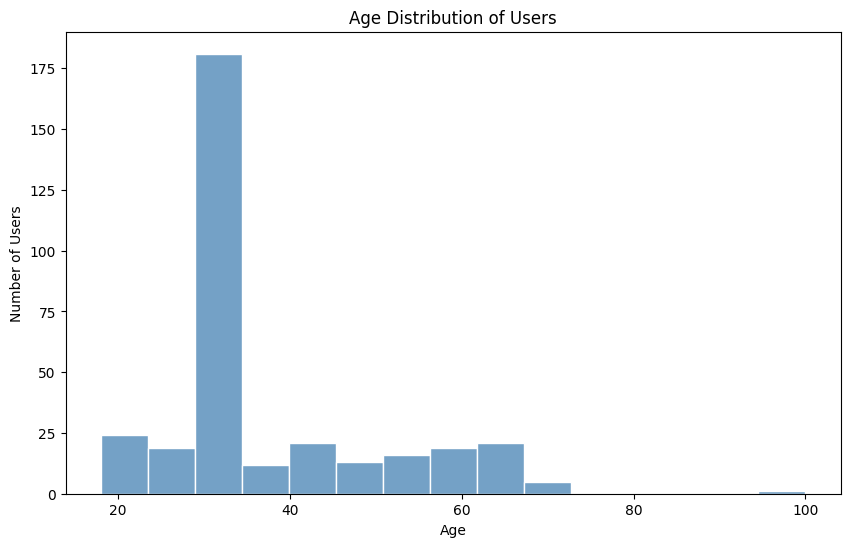

In [10]:
age_data = df['Age'].dropna()

# Step 2 — set the figure size
plt.figure(figsize=(10, 6))

# Step 3 — draw the histogram
sns.histplot(age_data, bins=15, color='steelblue', edgecolor='white')

# Step 4 — add labels and title
plt.title('Age Distribution of Users')
plt.xlabel('Age')
plt.ylabel('Number of Users')

# Step 5 — display the chart
plt.show()

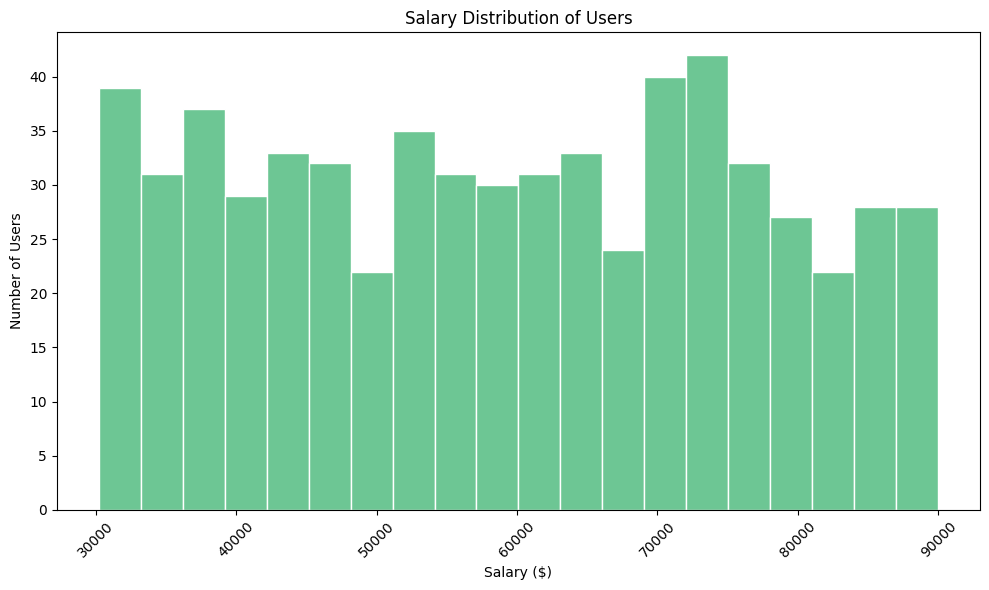

In [11]:
# Step 1 — drop NaN values from Salary locally
salary_data = df['Salary'].dropna()

# Step 2 — set the figure size
plt.figure(figsize=(10, 6))

# Step 3 — draw the histogram
sns.histplot(salary_data, bins=20, color='mediumseagreen', edgecolor='white')

# Step 4 — format x-axis to show proper money values
plt.xticks(rotation=45)

# Step 5 — add labels and title
plt.title('Salary Distribution of Users')
plt.xlabel('Salary ($)')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

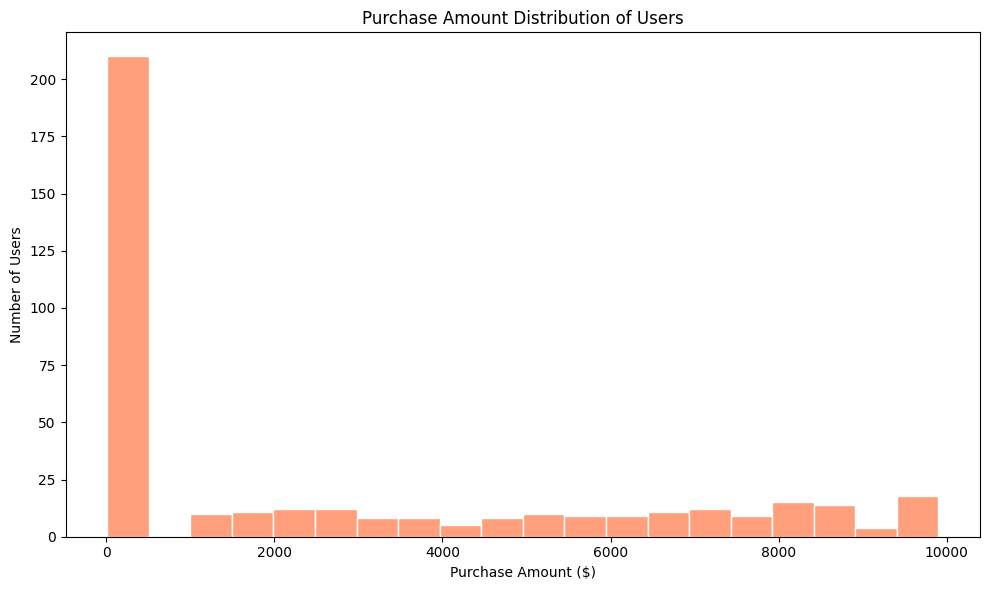

In [12]:
# Step 1 — drop NaN values from Purchase_Amount locally
purchase_data = df['Purchase_Amount'].dropna()

# Step 2 — set figure size
plt.figure(figsize=(10, 6))

# Step 3 — draw the histogram
sns.histplot(purchase_data, bins=20, color='coral', edgecolor='white')

# Step 4 — add labels and title
plt.title('Purchase Amount Distribution of Users')
plt.xlabel('Purchase Amount ($)')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

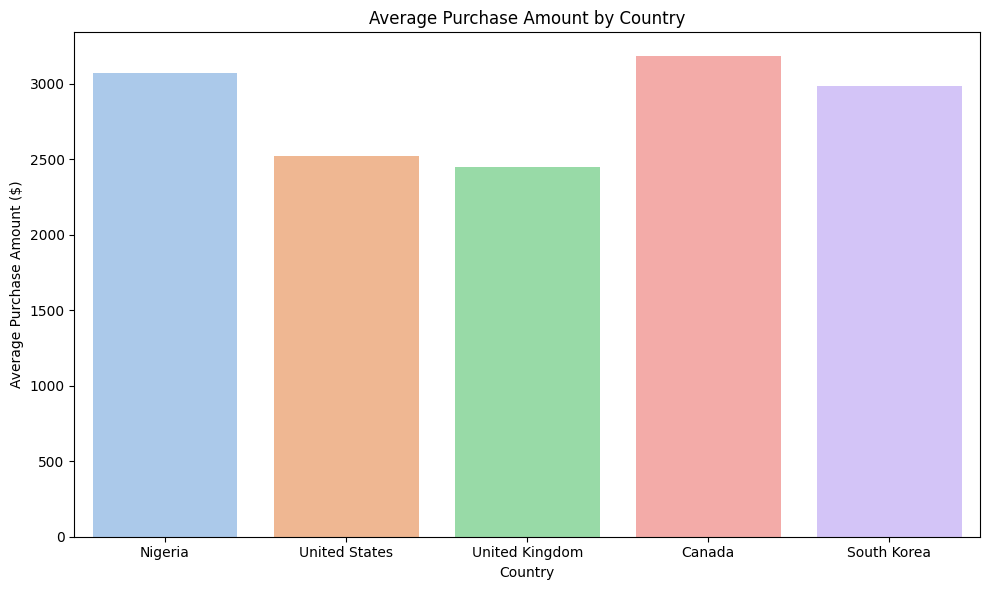

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Country',
    y='Purchase_Amount',
    data=df,
    estimator=np.mean,
    errorbar=None,        # fixes warning 1 — replaces ci=None
    hue='Country',        # fixes warning 2 — assigns hue explicitly
    palette='pastel',
    legend=False          # hides the unnecessary legend since x and hue are the same
)

plt.title('Average Purchase Amount by Country')
plt.xlabel('Country')
plt.ylabel('Average Purchase Amount ($)')
plt.tight_layout()
plt.show()



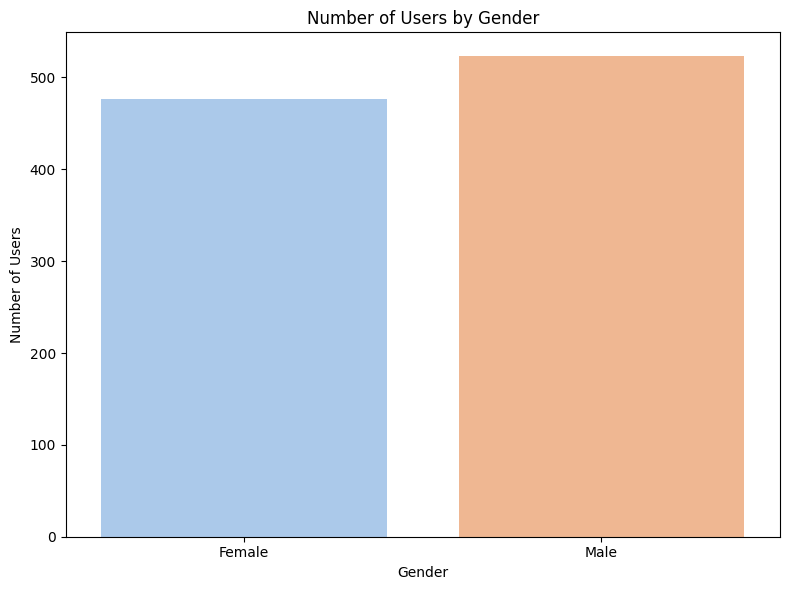

In [14]:
plt.figure(figsize=(8, 6))

sns.countplot(
    x='Gender',
    data=df,
    hue='Gender',
    palette='pastel',
    legend=False
)

plt.title('Number of Users by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

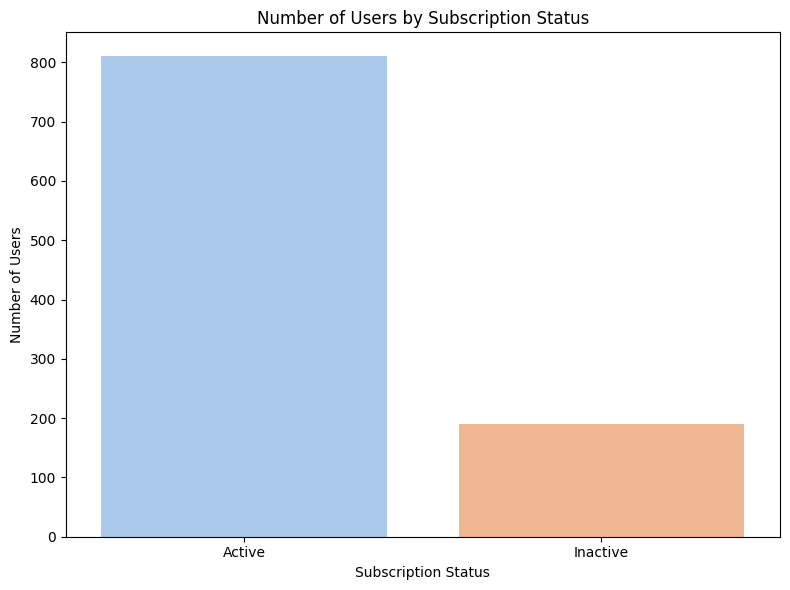

In [15]:
plt.figure(figsize=(8, 6))

sns.countplot(
    x='Subscription_Status',
    data=df,
    hue='Subscription_Status',
    palette='pastel',
    legend=False
)

plt.title('Number of Users by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

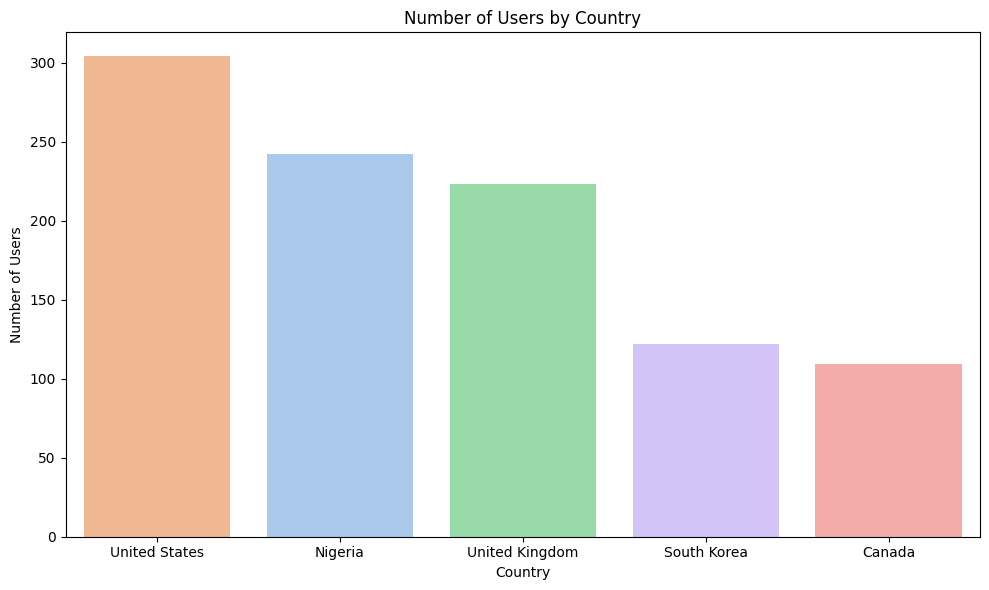

In [16]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x='Country',
    data=df,
    hue='Country',
    palette='pastel',
    legend=False,
    order=df['Country'].value_counts().index  # orders bars from highest to lowest
)

plt.title('Number of Users by Country')
plt.xlabel('Country')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

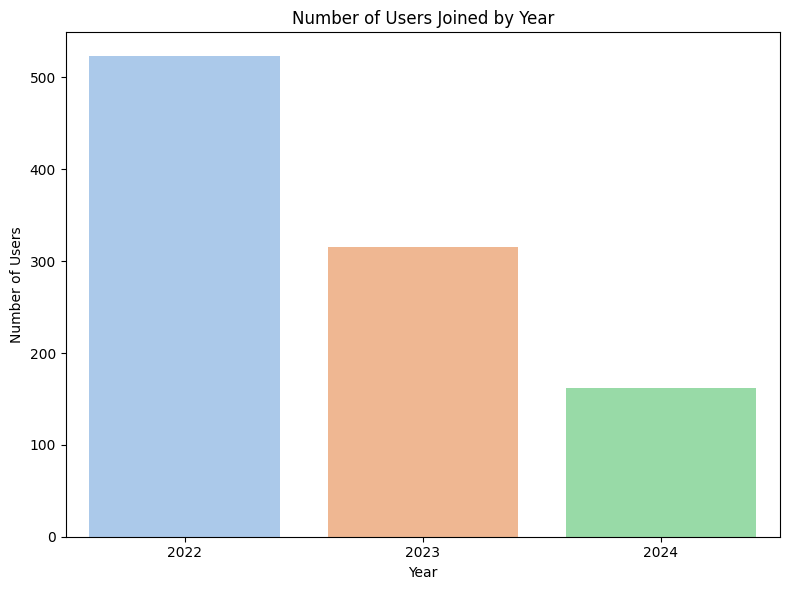

In [17]:
# extract the year from Join_Date column
df['Join_Year'] = df['Join_Date'].dt.year

plt.figure(figsize=(8, 6))

sns.countplot(
    x='Join_Year',
    data=df,
    hue='Join_Year',
    palette='pastel',
    legend=False
)

plt.title('Number of Users Joined by Year')
plt.xlabel('Year')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

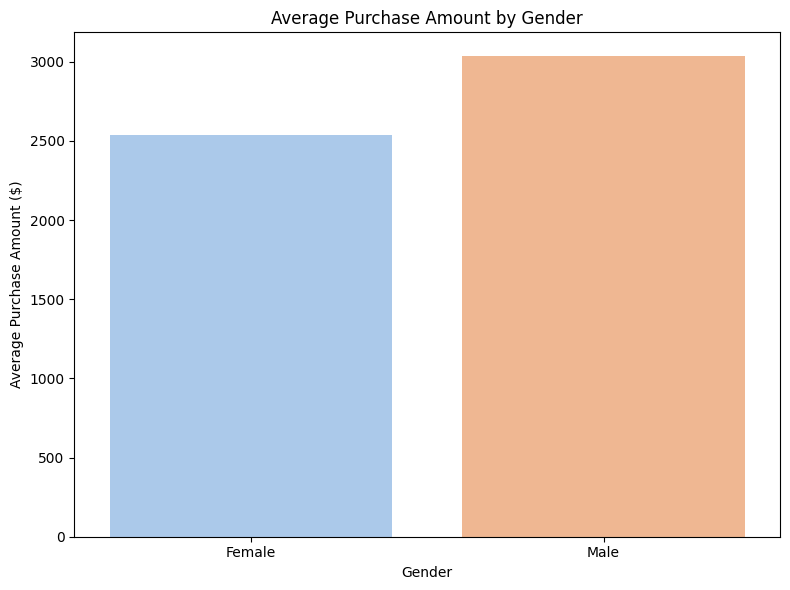

In [18]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x='Gender',
    y='Purchase_Amount',
    data=df,
    estimator=np.mean,
    errorbar=None,
    hue='Gender',
    palette='pastel',
    legend=False
)

plt.title('Average Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Purchase Amount ($)')

plt.tight_layout()
plt.show()

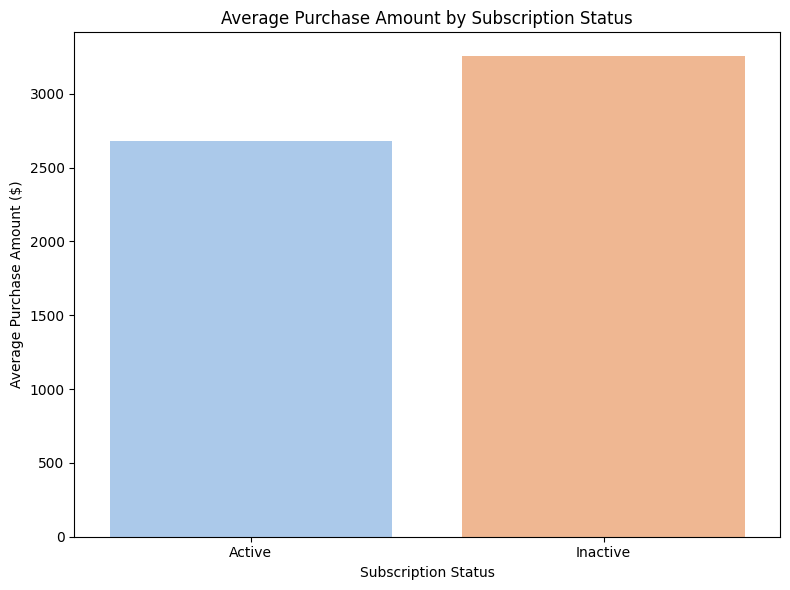

In [19]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x='Subscription_Status',
    y='Purchase_Amount',
    data=df,
    estimator=np.mean,
    errorbar=None,
    hue='Subscription_Status',
    palette='pastel',
    legend=False
)

plt.title('Average Purchase Amount by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Average Purchase Amount ($)')

plt.tight_layout()
plt.show()

In [20]:
# IMPORT MACHINE LEANRNING LIBRARIES
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [21]:
# select the columns we'll use to make predictions (features)
features = ['Salary', 'Purchase_Amount', 'Gender', 'Country']

# select the column we want to predict (target)
target = 'Subscription_Status'

# create a working copy with only the columns we need, drop rows with NaN
ml_data = df[features + [target]].dropna()

# convert Gender and Country from text to numbers (ML models only understand numbers)
ml_data = pd.get_dummies(ml_data, columns=['Gender', 'Country'])

print(ml_data.shape)
print(ml_data.head())

(255, 10)
     Salary  Purchase_Amount Subscription_Status  Gender_Female  Gender_Male  \
7   31276.0           127.33            Inactive          False         True   
11  57648.0          8260.00              Active           True        False   
17  30232.0          8239.00              Active           True        False   
20  51512.0          7548.00            Inactive          False         True   
23  58952.0           241.86            Inactive           True        False   

    Country_Canada  Country_Nigeria  Country_South Korea  \
7            False             True                False   
11           False            False                False   
17           False            False                False   
20           False            False                False   
23           False            False                False   

    Country_United Kingdom  Country_United States  
7                    False                  False  
11                    True                  

In [22]:
# separate features (X) from target (y)
X = ml_data.drop(columns=['Subscription_Status'])
y = ml_data['Subscription_Status']

# split — 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 204
Testing rows: 51


In [23]:
# create the model
model = DecisionTreeClassifier(random_state=42)

# train it on the training data
model.fit(X_train, y_train)

print('Model trained successfully!')

Model trained successfully!


In [24]:
# use the model to make predictions on the test data
y_pred = model.predict(X_test)

# check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# detailed breakdown
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.69

              precision    recall  f1-score   support

      Active       0.77      0.85      0.80        39
    Inactive       0.25      0.17      0.20        12

    accuracy                           0.69        51
   macro avg       0.51      0.51      0.50        51
weighted avg       0.65      0.69      0.66        51



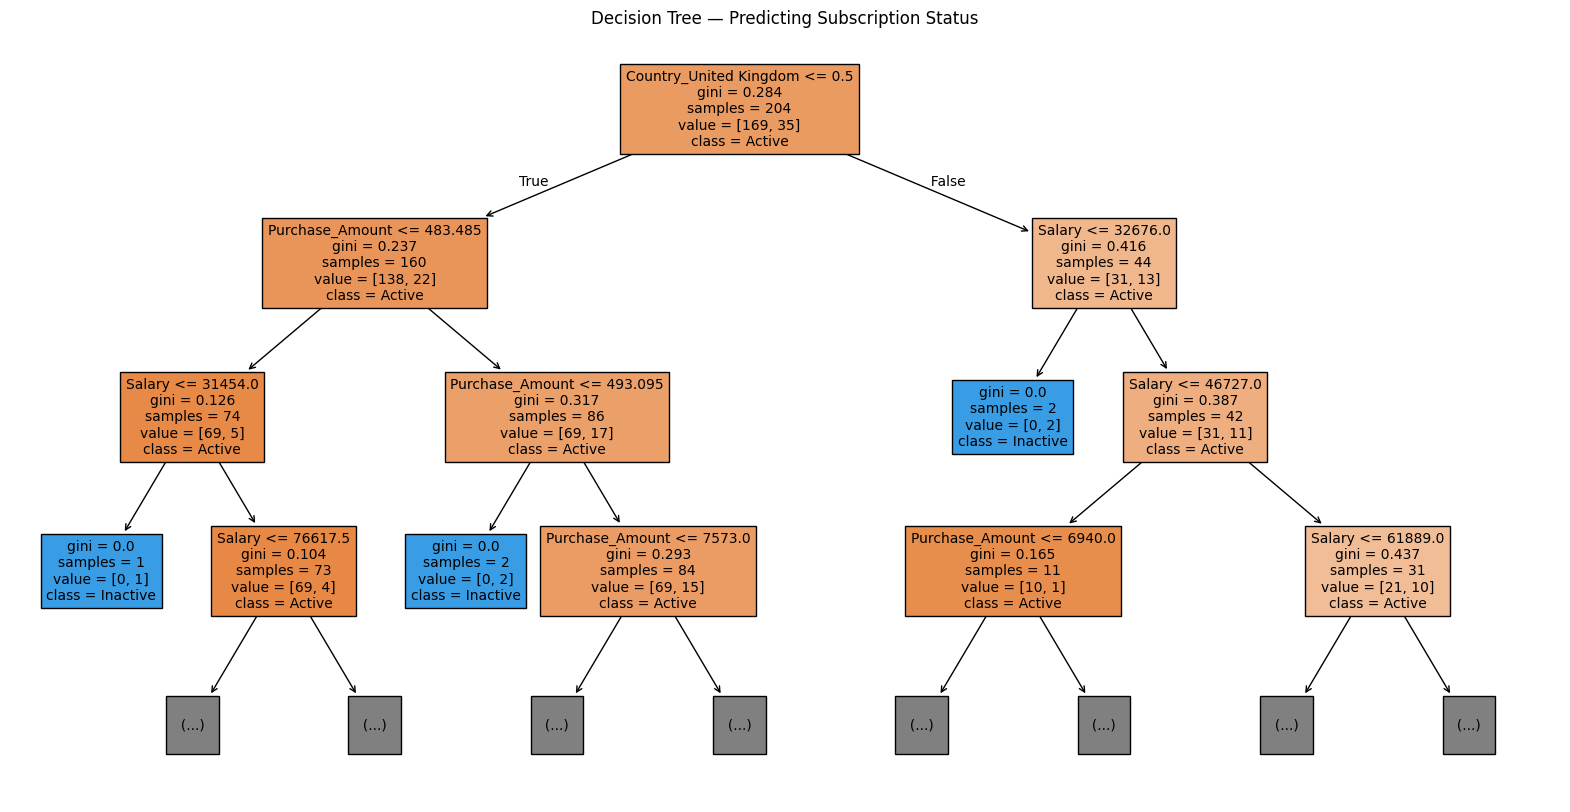

In [25]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=['Active', 'Inactive'],
    filled=True,
    max_depth=3,      
    fontsize=10
)

plt.title('Decision Tree — Predicting Subscription Status')
plt.show()